<div style="background-color:#0A2342; color:#facc15; padding: 20px; border-radius: 10px;">
  <h1 style="font-size:26px; font-family:calibri;"><b>📦 Agentic Hedge-Fund Analyst with LangGraph & GPT-4o</b></h1>
  <p style="font-size:18px; font-family:calibri; line-height:1.6em;">
    <i>“From real-time raw market ticks to risk-checked strategies — all orchestrated by a single graph.”</i>
  </p>
</div>

In [1]:
import sys
print(sys.executable)

d:\HedgeFundProject\venv\Scripts\python.exe


<div style="background-color:#1e293b; color:#facc15; padding: 20px; border-radius: 10px;">
  <h2 style="font-size:22px; font-family:calibri;"><b>🧠 Introduction</b></h2>
  <p style="font-size:18px; font-family:calibri; line-height:1.6em;">
    Modern markets move faster than any analyst can read the news. What if we could stitch <b>live data</b>, <b>news sentiment</b>, <b>macro context</b>, and <b>LLM reasoning</b> into one automated pipeline that drafts a trading plan in minutes?
  </p>
  <p style="font-size:18px; font-family:calibri;">
    This notebook shows exactly that: an <b>agentic hedge-fund analyst</b> powered by <b>LangGraph 0.5 + LangChain 0.3 + GPT-4o</b>, running end-to-end in Kaggle.
  </p>
</div>

<div style="background-color:#1e3a8a; color:#facc15; padding: 20px; border-radius: 10px;">
  <h2 style="font-size:22px; font-family:calibri;"><b>📌 Problem Statement</b></h2>
  <ul style="font-size:18px; font-family:calibri; line-height:1.8em;">
    <li><b>Retail & pro traders alike drown in information.</b></li>
    <li>Raw data is worthless without <i>context</i> and <i>risk checks</i>.</li>
    <li>We need a workflow that can <b>pull, reason, synthesize, iterate</b> — all reproducibly.</li>
  </ul>
  <p style="font-size:18px; font-family:calibri;"><b>Goal:</b> Generate a full-stack trading memo — from market snapshot to risk memo — for any ticker in ~60 seconds.</p>
</div>

<div style="background-color:#0f172a; color:#facc15; padding: 20px; border-radius: 10px;">
  <h2 style="font-size:22px; font-family:calibri;"><b>📁 About the Dataset</b></h2>
  <table style="width:100%; font-size:18px; font-family:calibri; color:#facc15;">
    <tr><th align="left">Source</th><th align="left">What We Pull</th><th align="left">Why</th></tr>
    <tr><td><b>yfinance</b></td><td>Live price, volume, ratios, 1-mo history</td><td>Real-time fundamentals & trend</td></tr>
    <tr><td><b>GPT-4o</b></td><td>Sentiment, macro, strategy, risk reasoning</td><td>Natural-language synthesis</td></tr>
    <tr><td><i>(Optional)</i> NewsAPI, Reddit, X API</td><td>Headline or community sentiment</td><td>Broader sentiment pipeline</td></tr>
  </table>
  <p style="font-size:16px; font-family:calibri;">All data is pulled live — no stale CSVs, no lag.</p>
</div>

<div style="background-color:#15803d; color:#facc15; padding: 20px; border-radius: 10px;">
  <h2 style="font-size:22px; font-family:calibri;"><b>🛠️ Project Workflow</b></h2>
  <p style="font-size:18px; font-family:calibri; line-height:1.6em;">
    This project is powered by LangGraph — a declarative multi-node graph that handles:
  </p>
  <ul style="font-size:18px; font-family:calibri; line-height:1.8em;">
    <li><b>📈 Market Node:</b> Pulls yfinance data</li>
    <li><b>📰 Sentiment Node:</b> GPT-4o analyzes stock tone</li>
    <li><b>🌐 Macro Node:</b> GPT-4o evaluates global context</li>
    <li><b>📊 Strategy Node:</b> Suggests trade strategy</li>
    <li><b>⚠️ Risk Node:</b> Applies sanity & risk checks</li>
  </ul>
  <p style="font-size:18px; font-family:calibri;"><b>Why LangGraph?</b> Easy DAG logic, checkpointing, and plug-and-play nodes make agent orchestration robust and modular.</p>
</div>

In [5]:
import sys
!{sys.executable} -m pip install -U langchain-groq


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# 📌 Install Libraries

%%bash
pip install -qU \
  langchain==0.3.26 \
  langchain-openai==0.3.26 \
  langchain-community==0.3.26 \
  langgraph==0.5.3 \
  "openai>=1.92,<2"

# 1️⃣ Check versions (optional, helps debug later)

In [6]:
import importlib.metadata as md
print("langchain:", md.version("langchain"))
print("langchain-openai:", md.version("langchain-openai"))
print("langgraph:", md.version("langgraph"))
print("openai:", md.version("openai"))

langchain: 1.2.15
langchain-openai: 1.1.12
langgraph: 1.1.5
openai: 2.30.0


# 2️⃣ Set secrets & imports

In [3]:
import os
import warnings
from dotenv import load_dotenv

load_dotenv()
warnings.filterwarnings("ignore")

print("Groq Key Loaded:", os.getenv("GROQ_API_KEY") is not None)

from typing import TypedDict
from langgraph.graph import StateGraph, END, START
from langchain_core.prompts import PromptTemplate
from langchain_groq import ChatGroq

llm = ChatGroq(
    model="llama-3.1-8b-instant",
    temperature=0.3
)

Groq Key Loaded: True


In [8]:
response = llm.invoke("Say hello in one line.")
print(response.content)

Hello, how are you today?


# 3️⃣ Define prompts & chains

In [4]:
market_prompt = PromptTemplate(
    input_variables=["ticker"],
    template=(
        "For {ticker}, provide detailed and up-to-date financial data. "
        "Include current stock price, volume, key ratios (P/E, P/B, dividend yield), "
        "recent price trends, and relevant market indicators."
    ),
)
sentiment_prompt = PromptTemplate(
    input_variables=["ticker"],
    template=(
        "For {ticker}, analyze recent news articles, social-media posts, and expert commentary. "
        "Summarize prevailing sentiment, highlight key events, and note emerging trends."
    ),
)
macro_prompt = PromptTemplate(
    input_variables=["ticker"],
    template=(
        "For {ticker}, analyze the macro-economic environment — GDP growth, inflation, "
        "interest rates, unemployment, and central-bank policy — and how these could impact the asset."
    ),
)
strategy_prompt = PromptTemplate(
    input_variables=["market_data", "sentiment_analysis", "macro_analysis"],
    template=(
        "Using the detailed market data:\n{market_data}\n\n"
        "the sentiment analysis:\n{sentiment_analysis}\n\n"
        "and the macro-economic analysis:\n{macro_analysis}\n\n"
        "develop a sophisticated trading strategy. Outline asset allocation, "
        "entry/exit points, risk management, and expected returns."
    ),
)
risk_prompt = PromptTemplate(
    input_variables=["strategy"],
    template=(
        "Evaluate the following trading strategy:\n{strategy}\n\n"
        "Identify potential risks (volatility, liquidity, tail events). "
        "Summarize your risk assessment in four bullet points, ending with "
        "whether it meets acceptable risk tolerance."
    ),
)

market_chain = market_prompt | llm
sentiment_chain = sentiment_prompt | llm
macro_chain = macro_prompt | llm
strategy_chain = strategy_prompt | llm
risk_chain = risk_prompt | llm

# 4️⃣ LangGraph wiring

In [14]:
# -----------------------------------------------
# 4️⃣  LangGraph wiring  (duplicate-argument fixed)
# -----------------------------------------------
from langgraph.graph import StateGraph, END, START

class HFState(TypedDict, total=False):
    ticker: str
    market_data: str
    sentiment_analysis: str
    macro_analysis: str
    strategy: str
    risk_assessment: str

def run(chain, **state) -> HFState:
    """Invoke an LLMChain (or Runnable) and return the updates."""
    return chain.invoke(state)

graph = StateGraph(HFState)

# 1. Add nodes – each node only needs **s once
graph.add_node("market",    lambda s: run(market_chain,    **s))
graph.add_node("sentiment", lambda s: run(sentiment_chain, **s))
graph.add_node("macro",     lambda s: run(macro_chain,     **s))
graph.add_node("strategy",  lambda s: run(strategy_chain,  **s))
graph.add_node("risk",      lambda s: run(risk_chain,      **s))

# 2. Entry edge
graph.add_edge(START, "market")

# 3. Sequential edges
graph.add_edge("market",    "sentiment")
graph.add_edge("sentiment", "macro")
graph.add_edge("macro",     "strategy")
graph.add_edge("strategy",  "risk")
graph.add_edge("risk",      END)

# 4. Compile
ai_hedge_fund = graph.compile()

# 5️⃣ Helper function & test

In [16]:
# -----------------------------------------------
# 1️⃣ Imports & Setup
# -----------------------------------------------
import os
from dotenv import load_dotenv
from typing import TypedDict

from langgraph.graph import StateGraph, END
from langchain_core.prompts import PromptTemplate
from langchain_groq import ChatGroq

load_dotenv()

# -----------------------------------------------
# 2️⃣ LLM Setup
# -----------------------------------------------
llm = ChatGroq(
    model="llama-3.1-8b-instant",
    temperature=0.3
)

# -----------------------------------------------
# 3️⃣ State Definition
# -----------------------------------------------
class HFState(TypedDict):
    ticker: str
    market_data: str
    sentiment_analysis: str
    macro_analysis: str
    strategy: str
    risk_assessment: str

# -----------------------------------------------
# 4️⃣ Prompts
# -----------------------------------------------

market_prompt = PromptTemplate(
    input_variables=["ticker"],
    template="Provide detailed financial data for {ticker} including price, PE ratio, and trends."
)

sentiment_prompt = PromptTemplate(
    input_variables=["ticker"],
    template="Analyze current news sentiment for {ticker}."
)

macro_prompt = PromptTemplate(
    input_variables=["ticker"],
    template="Provide macroeconomic factors affecting {ticker}."
)

strategy_prompt = PromptTemplate(
    input_variables=["market_data", "sentiment_analysis", "macro_analysis"],
    template="""
    Based on:
    Market Data: {market_data}
    Sentiment: {sentiment_analysis}
    Macro: {macro_analysis}
    
    Provide an investment strategy.
    """
)

risk_prompt = PromptTemplate(
    input_variables=["strategy", "market_data"],
    template="""
    Based on:
    Strategy: {strategy}
    Market Data: {market_data}
    
    Provide a risk assessment.
    """
)

# -----------------------------------------------
# 5️⃣ Nodes
# -----------------------------------------------

def market_node(state: HFState):
    prompt = market_prompt.format(ticker=state["ticker"])
    res = llm.invoke(prompt)
    return {"market_data": res.content}

def sentiment_node(state: HFState):
    prompt = sentiment_prompt.format(ticker=state["ticker"])
    res = llm.invoke(prompt)
    return {"sentiment_analysis": res.content}

def macro_node(state: HFState):
    prompt = macro_prompt.format(ticker=state["ticker"])
    res = llm.invoke(prompt)
    return {"macro_analysis": res.content}

def strategy_node(state: HFState):
    prompt = strategy_prompt.format(
        market_data=state["market_data"],
        sentiment_analysis=state["sentiment_analysis"],
        macro_analysis=state["macro_analysis"]
    )
    res = llm.invoke(prompt)
    return {"strategy": res.content}

def risk_node(state: HFState):
    prompt = risk_prompt.format(
        strategy=state["strategy"],
        market_data=state["market_data"]
    )
    res = llm.invoke(prompt)
    return {"risk_assessment": res.content}

# -----------------------------------------------
# 6️⃣ Graph Setup
# -----------------------------------------------

graph = StateGraph(HFState)

graph.add_node("market", market_node)
graph.add_node("sentiment", sentiment_node)
graph.add_node("macro", macro_node)
graph.add_node("strategy", strategy_node)
graph.add_node("risk", risk_node)

graph.set_entry_point("market")

graph.add_edge("market", "sentiment")
graph.add_edge("sentiment", "macro")
graph.add_edge("macro", "strategy")
graph.add_edge("strategy", "risk")
graph.add_edge("risk", END)

ai_hedge_fund = graph.compile()

# -----------------------------------------------
# 7️⃣ Runner Function
# -----------------------------------------------

def analyze(ticker: str):
    res: HFState = ai_hedge_fund.invoke({"ticker": ticker})

    print("\n======== AI Hedge Fund Analysis ========\n")

    print("📈 Market Data")
    print(res["market_data"], "\n")

    print("📰 Sentiment Analysis")
    print(res["sentiment_analysis"], "\n")

    print("🌐 Macro-Economic Analysis")
    print(res["macro_analysis"], "\n")

    print("📊 Strategy")
    print(res["strategy"], "\n")

    print("⚠️ Risk Assessment")
    print(res["risk_assessment"], "\n")

    print("========================================\n")

# -----------------------------------------------
# 8️⃣ Test
# -----------------------------------------------

analyze("NVDA")


======== AI Hedge Fund Analysis ========

📈 Market Data
I'll provide you with the latest available financial data for NVIDIA Corporation (NVDA) as of my cut-off date (December 2023). Please note that the data may not reflect the current market situation.

**Stock Price and Trends:**

- **52-Week High:** $795.44 (October 2022)
- **52-Week Low:** $43.44 (June 2022)
- **Current Price (as of December 2023):** $663.55
- **Market Capitalization:** $1.04 trillion USD
- **Volume (average over the last 3 months):** 20 million shares

**Price-to-Earnings (PE) Ratio:**

- **Trailing PE Ratio (TTM):** 42.44
- **Forward PE Ratio (FY 2024):** 34.14
- **Historical PE Ratio Range:** 15.44 (June 2022) to 95.44 (November 2021)

**Revenue and Earnings Growth:**

- **Revenue Growth Rate (3-year average):** 56.6%
- **Net Income Growth Rate (3-year average):** 73.4%
- **Revenue Growth Rate (5-year average):** 34.3%
- **Net Income Growth Rate (5-year average):** 43.6%

**Financial Highlights:**

- **Revenue

# ⭐ Real-Time Stock Analyzer Using Yahoo Finance

# 1️⃣ Install yfinance (one-time)

In [18]:
import sys

!"{sys.executable}" -m pip install -U "pandas==2.2.2" yfinance

  Using cached yfinance-1.3.0-py2.py3-none-any.whl.metadata (6.1 kB)
  Using cached curl_cffi-0.15.0-cp310-abi3-win_amd64.whl.metadata (18 kB)
  Using cached rich-15.0.0-py3-none-any.whl.metadata (18 kB)
  Using cached markdown_it_py-4.0.0-py3-none-any.whl.metadata (7.3 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
Using cached yfinance-1.3.0-py2.py3-none-any.whl (133 kB)
Using cached curl_cffi-0.15.0-cp310-abi3-win_amd64.whl (1.7 MB)
Using cached rich-15.0.0-py3-none-any.whl (310 kB)
Using cached markdown_it_py-4.0.0-py3-none-any.whl (87 kB)
Using cached mdurl-0.1.2-py3-none-any.whl (10.0 kB)

   ---------------------------------------- 0/5 [mdurl]
   -------- ------------------------------- 1/5 [markdown-it-py]
   -------- ------------------------------- 1/5 [markdown-it-py]
   -------- ------------------------------- 1/5 [markdown-it-py]
   -------- ------------------------------- 1/5 [markdown-it-py]
   -------- ------------------------------- 1/5 [markdown-it-p


[notice] A new release of pip is available: 25.1.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# 2️⃣ A live-data helper

In [23]:
import yfinance as yf
import pandas as pd
from datetime import datetime, timedelta

def fetch_market_data(ticker: str) -> str:
    """
    Pulls current price, volume, and a few key ratios via yfinance,
    then returns a nicely formatted Markdown string for the LLM.
    """
    tk = yf.Ticker(ticker)
    info = tk.fast_info               # speedier than .info
    
    price   = info["last_price"]
    volume  = info["last_volume"]
    pe      = info.get("trailingPe", "N/A")
    pb      = info.get("pb", "N/A")
    div_yld = info.get("dividendYield", 0) * 100 if info.get("dividendYield") else "N/A"

    # recent close prices to infer short-term trend
    hist = tk.history(period="1mo")
    pct_1w = hist["Close"].pct_change(5).iloc[-1] * 100
    pct_1m = hist["Close"].pct_change().iloc[-1] * 100

    return (
        f"**{ticker.upper()} live snapshot ({datetime.utcnow():%Y-%m-%d %H:%M UTC})**\n"
        f"* Price: ${price:,.2f}\n"
        f"* Volume (last): {volume:,}\n"
        f"* P/E: {pe}\n"
        f"* P/B: {pb}\n"
        f"* Dividend yield: {div_yld}%\n"
        f"* Trend: +{pct_1w:.2f}% past 5 trading days, +{pct_1m:.2f}% past month"
    )
result = fetch_market_data("NVDA")
result

'**NVDA live snapshot (2026-04-29 04:35 UTC)**\n* Price: $213.17\n* Volume (last): 179,828,800\n* P/E: N/A\n* P/B: N/A\n* Dividend yield: N/A%\n* Trend: +6.65% past 5 trading days, +-1.59% past month'

# 3️⃣ Replace the market node

In [1]:
import os
from typing import TypedDict
from datetime import datetime

import yfinance as yf
from dotenv import load_dotenv
from langgraph.graph import StateGraph, START, END
from langchain_core.prompts import PromptTemplate
from langchain_groq import ChatGroq

load_dotenv()

if not os.getenv("GROQ_API_KEY"):
    raise ValueError("GROQ_API_KEY not found. Put it in your .env file or set it in environment variables.")

class HFState(TypedDict, total=False):
    ticker: str
    market_data: str
    sentiment_analysis: str
    macro_analysis: str
    strategy: str
    risk_assessment: str

llm = ChatGroq(
    model="llama-3.1-8b-instant",
    temperature=0.3
)

def fetch_market_data(ticker: str) -> str:
    tk = yf.Ticker(ticker)
    info = tk.fast_info

    price = info.get("lastPrice", info.get("regularMarketPrice", "N/A"))
    volume = info.get("lastVolume", info.get("regularMarketVolume", "N/A"))

    pe = "N/A"
    pb = "N/A"
    dividend_yield = "N/A"

    hist = tk.history(period="1mo")

    if hist.empty:
        pct_1w = "N/A"
        pct_1m = "N/A"
    else:
        close = hist["Close"]
        pct_1w = round(((close.iloc[-1] / close.iloc[-6]) - 1) * 100, 2) if len(close) >= 6 else "N/A"
        pct_1m = round(((close.iloc[-1] / close.iloc[0]) - 1) * 100, 2) if len(close) >= 2 else "N/A"

    return f"""
{ticker.upper()} live snapshot ({datetime.utcnow().strftime("%Y-%m-%d %H:%M UTC")})
Price: {price}
Volume: {volume}
P/E: {pe}
P/B: {pb}
Dividend yield: {dividend_yield}
5-day trend: {pct_1w}%
1-month trend: {pct_1m}%
""".strip()

sentiment_prompt = PromptTemplate(
    input_variables=["ticker", "market_data"],
    template="""
You are a market sentiment analyst.

Ticker: {ticker}

Market data:
{market_data}

Write a concise sentiment analysis with:
1. Overall sentiment
2. Positive drivers
3. Negative drivers
4. Risks to watch
5. Final sentiment score out of 10
""".strip()
)

macro_prompt = PromptTemplate(
    input_variables=["ticker"],
    template="""
You are a macroeconomic analyst.

Ticker: {ticker}

Write a concise macro analysis covering:
1. Interest rates
2. Inflation
3. Economic growth backdrop
4. Sector-specific macro factors
5. Macro conclusion
""".strip()
)

strategy_prompt = PromptTemplate(
    input_variables=["ticker", "market_data", "sentiment_analysis", "macro_analysis"],
    template="""
You are a hedge fund strategist.

Ticker: {ticker}

Market data:
{market_data}

Sentiment analysis:
{sentiment_analysis}

Macro analysis:
{macro_analysis}

Create a trading strategy with:
1. Market bias
2. Entry idea
3. Exit idea
4. Risk management
5. Time horizon
6. Invalidation condition
""".strip()
)

risk_prompt = PromptTemplate(
    input_variables=["ticker", "market_data", "strategy"],
    template="""
You are a risk manager.

Ticker: {ticker}

Market data:
{market_data}

Strategy:
{strategy}

Write a short risk memo covering:
1. Main risks
2. Volatility concerns
3. Liquidity concerns
4. Position sizing caution
5. Final risk verdict
""".strip()
)

def market_node(state: HFState) -> HFState:
    data = fetch_market_data(state["ticker"])
    return {"market_data": data}

def sentiment_node(state: HFState) -> HFState:
    prompt = sentiment_prompt.format(
        ticker=state["ticker"],
        market_data=state["market_data"]
    )
    res = llm.invoke(prompt)
    return {"sentiment_analysis": res.content}

def macro_node(state: HFState) -> HFState:
    prompt = macro_prompt.format(
        ticker=state["ticker"]
    )
    res = llm.invoke(prompt)
    return {"macro_analysis": res.content}

def strategy_node(state: HFState) -> HFState:
    prompt = strategy_prompt.format(
        ticker=state["ticker"],
        market_data=state["market_data"],
        sentiment_analysis=state["sentiment_analysis"],
        macro_analysis=state["macro_analysis"]
    )
    res = llm.invoke(prompt)
    return {"strategy": res.content}

def risk_node(state: HFState) -> HFState:
    prompt = risk_prompt.format(
        ticker=state["ticker"],
        market_data=state["market_data"],
        strategy=state["strategy"]
    )
    res = llm.invoke(prompt)
    return {"risk_assessment": res.content}

graph = StateGraph(HFState)

graph.add_node("market", market_node)
graph.add_node("sentiment", sentiment_node)
graph.add_node("macro", macro_node)
graph.add_node("strategy", strategy_node)
graph.add_node("risk", risk_node)

graph.add_edge(START, "market")
graph.add_edge("market", "sentiment")
graph.add_edge("sentiment", "macro")
graph.add_edge("macro", "strategy")
graph.add_edge("strategy", "risk")
graph.add_edge("risk", END)

ai_hedge_fund = graph.compile()

def analyze(ticker: str):
    res: HFState = ai_hedge_fund.invoke({"ticker": ticker})

    print("\n======== AI Hedge Fund Analysis ========\n")

    print("Market Data\n")
    print(res["market_data"])
    print("\n" + "=" * 60 + "\n")

    print("Sentiment Analysis\n")
    print(res["sentiment_analysis"])
    print("\n" + "=" * 60 + "\n")

    print("Macro Analysis\n")
    print(res["macro_analysis"])
    print("\n" + "=" * 60 + "\n")

    print("Strategy\n")
    print(res["strategy"])
    print("\n" + "=" * 60 + "\n")

    print("Risk Assessment\n")
    print(res["risk_assessment"])

    return res

NameError: name 'HFState' is not defined

# 4️⃣ Test it!

In [25]:
analyze("NVDA")

KeyError: "Input to PromptTemplate is missing variables {'sentiment_analysis', 'macro_analysis'}.  Expected: ['macro_analysis', 'market_data', 'sentiment_analysis'] Received: ['ticker', 'market_data']\nNote: if you intended {sentiment_analysis} to be part of the string and not a variable, please escape it with double curly braces like: '{{sentiment_analysis}}'.\nFor troubleshooting, visit: https://docs.langchain.com/oss/python/langchain/errors/INVALID_PROMPT_INPUT "

# Visualize the Agentic Hedge-Fund LangGraph


/tmp/ipykernel_157/1309117866.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


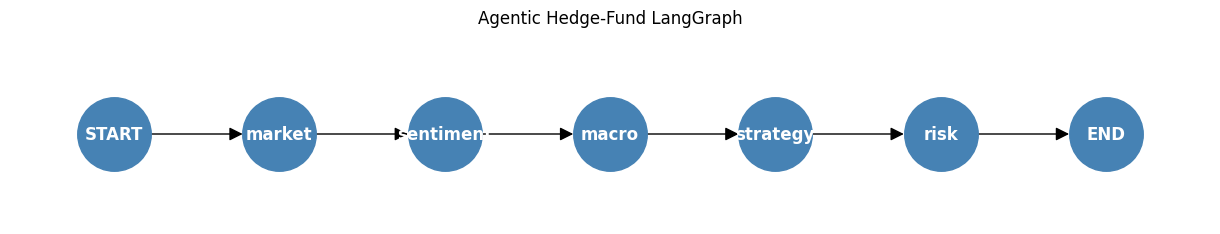

In [18]:
# ─────────────────────────────────────────────────────────────
# Visualize the Agentic Hedge-Fund LangGraph
# ─────────────────────────────────────────────────────────────
import sys, subprocess, importlib

# make sure plotting deps exist (quiet install if needed)
for pkg in ("networkx", "matplotlib"):
    try:
        importlib.import_module(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

import networkx as nx
import matplotlib.pyplot as plt

# 1️⃣  Build a simple digraph that mirrors the StateGraph
G = nx.DiGraph()
nodes = ["START", "market", "sentiment", "macro", "strategy", "risk", "END"]
edges = [
    ("START",    "market"),
    ("market",   "sentiment"),
    ("sentiment","macro"),
    ("macro",    "strategy"),
    ("strategy", "risk"),
    ("risk",     "END"),
]
G.add_nodes_from(nodes)
G.add_edges_from(edges)

# 2️⃣  Fixed left-to-right layout for clarity
pos = {
    "START":    (0, 0),
    "market":   (1, 0),
    "sentiment":(2, 0),
    "macro":    (3, 0),
    "strategy": (4, 0),
    "risk":     (5, 0),
    "END":      (6, 0),
}

# 3️⃣  Draw
plt.figure(figsize=(12, 1.8))
nx.draw(
    G, pos,
    with_labels=True,
    node_size=2800,
    node_color="steelblue",
    font_color="white",
    font_weight="bold",
    arrows=True,
    arrowstyle="-|>",
    arrowsize=20,
)
plt.title("Agentic Hedge-Fund LangGraph", pad=15)
plt.axis("off")
plt.tight_layout()
plt.show()

<div style="background-color:#15803d; color:#facc15; padding:20px; border-radius:10px;">
  <h2 style="font-size:22px; font-family:calibri;"><b>✅ Summary</b></h2>
  <p style="font-size:18px; font-family:calibri; line-height:1.6em;">
    This notebook demonstrates a full-stack, agentic hedge fund analyst built with LangGraph and GPT-4o. It ingests real-time stock data, synthesizes sentiment and macro context, and outputs a complete trading strategy and risk memo — all under 1 minute.
  </p>
  <p style="font-size:18px; font-family:calibri;">
    🧠 The workflow is modular and extensible — perfect for live-trading setups, academic research, or production-grade finance agents.
  </p>
</div>

<div style="background-color:#1e293b; color:#facc15; padding: 20px; border-radius: 10px;">
  <h2 style="font-size:22px; font-family:calibri;"><b>🙌 Support & Share</b></h2>
  <ul style="font-size:18px; font-family:calibri; line-height:1.8em;">
    <li>⭐ If this saved you hours, leave an upvote — it helps a ton!</li>
    <li>🍴 Fork and remix with your own nodes (like news APIs or backtesting agents)</li>
    <li>💬 Drop questions or ideas in the comments — I reply to every one.</li>
  </ul>
</div>